In [2]:
# Instalación de dependencias necesarias
!pip install opencv-python 
!pip install numpy 
!pip install scikit-learn 
!pip install matplotlib

     ---------------------------------------- 39.5/39.5 MB 8.1 MB/s eta 0:00:00


Analizando video: escena.mp4
Extrayendo 20 frames...
Se extrajeron 20 frames.


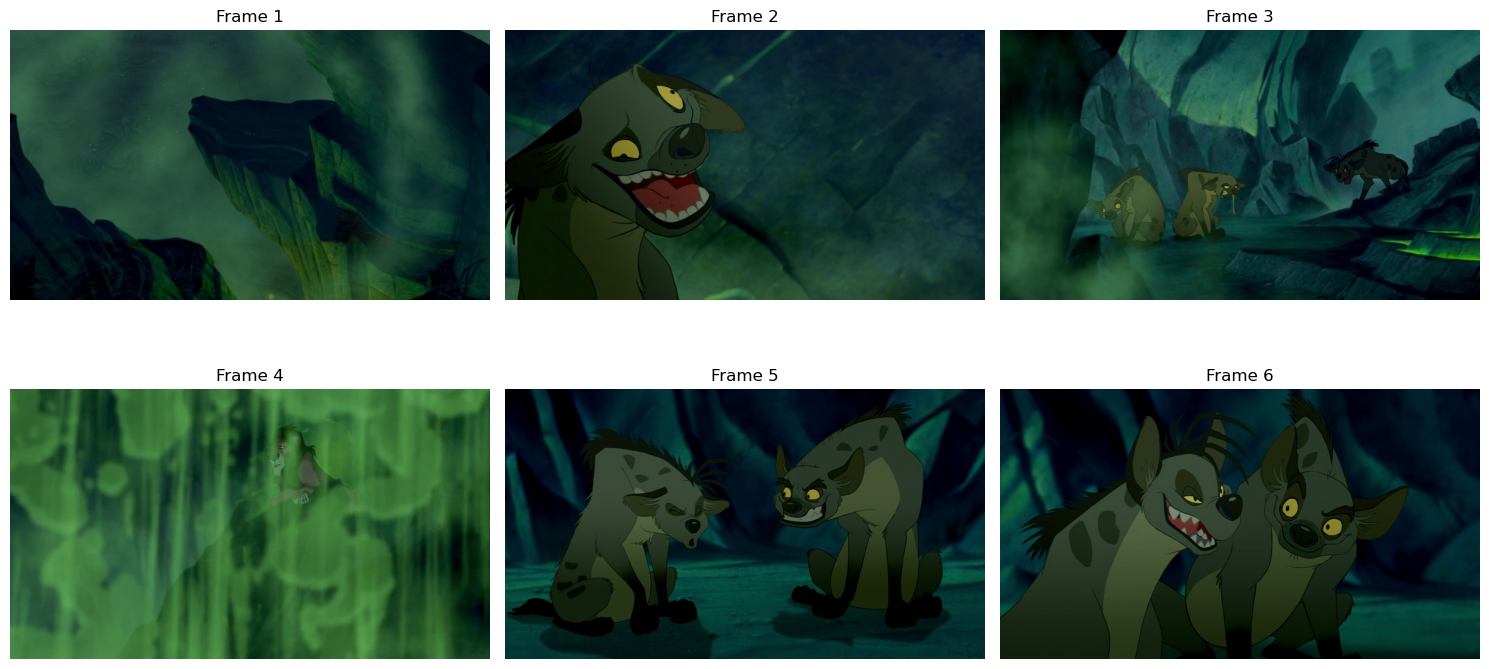


Analizando paletas de color por frame:


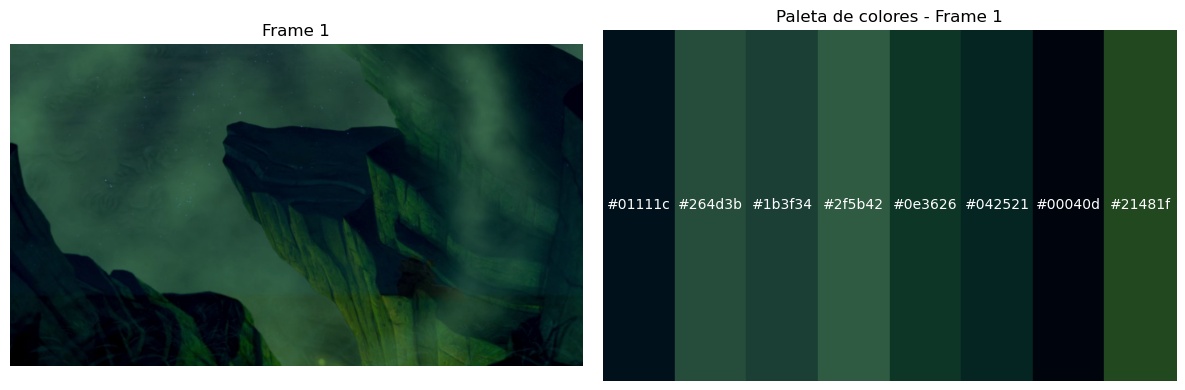

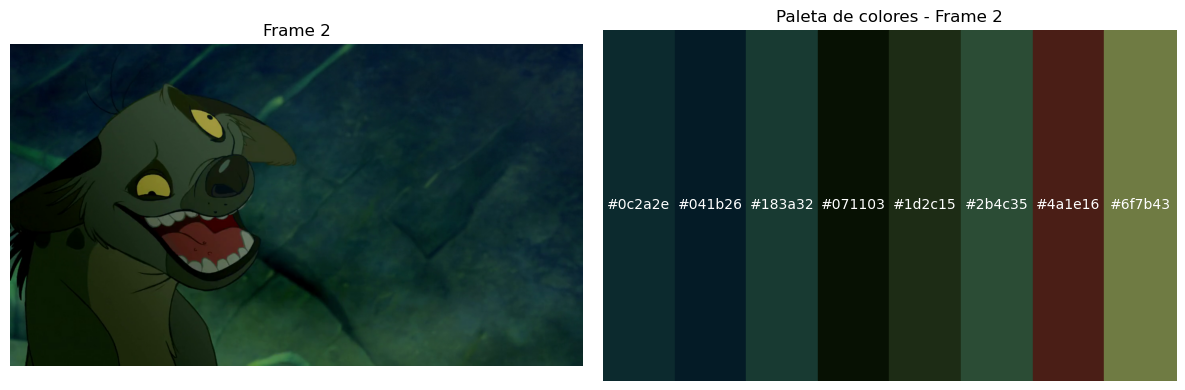

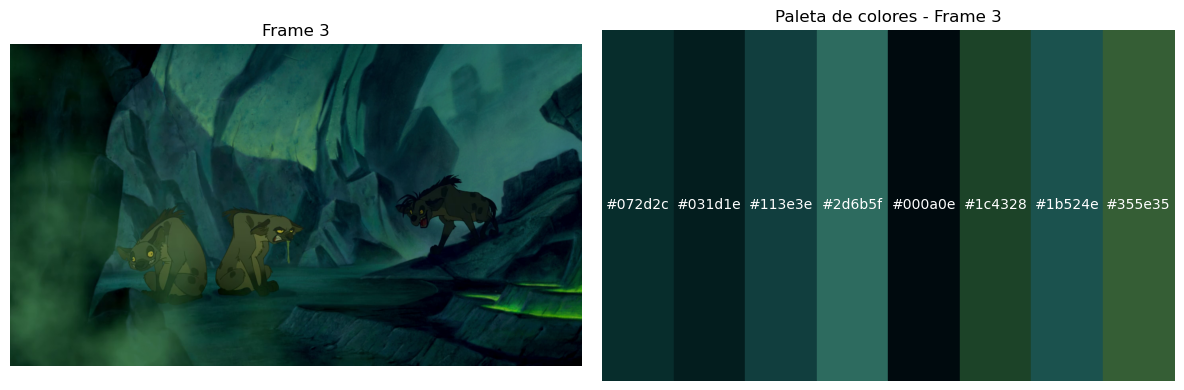

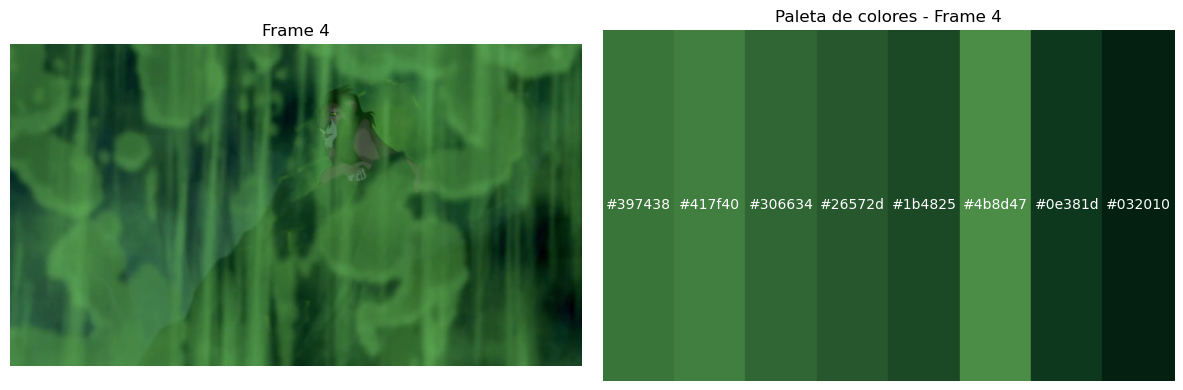

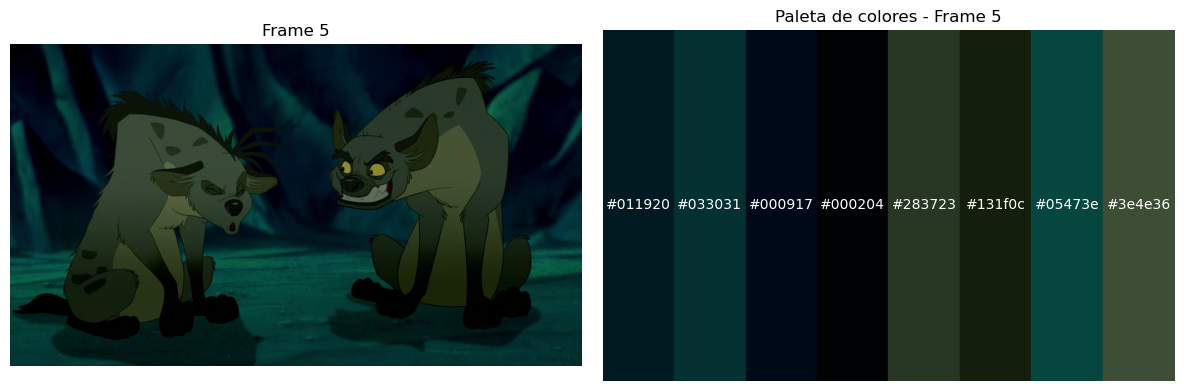

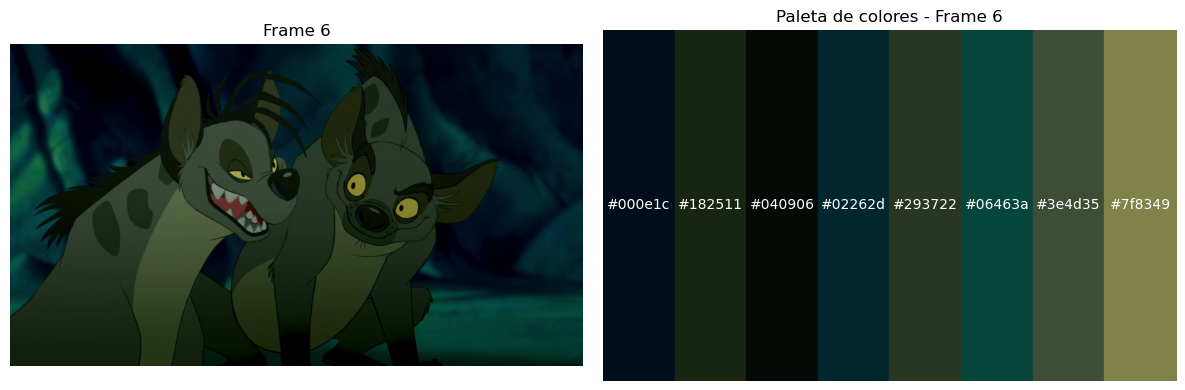

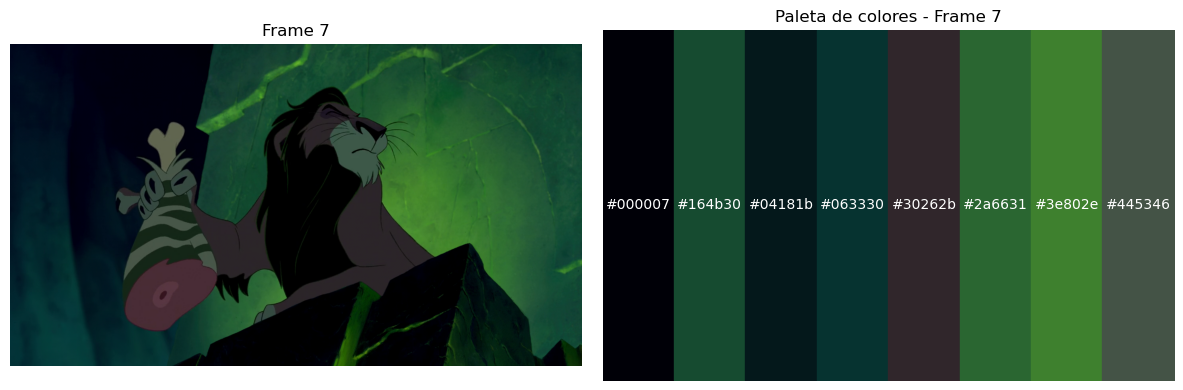

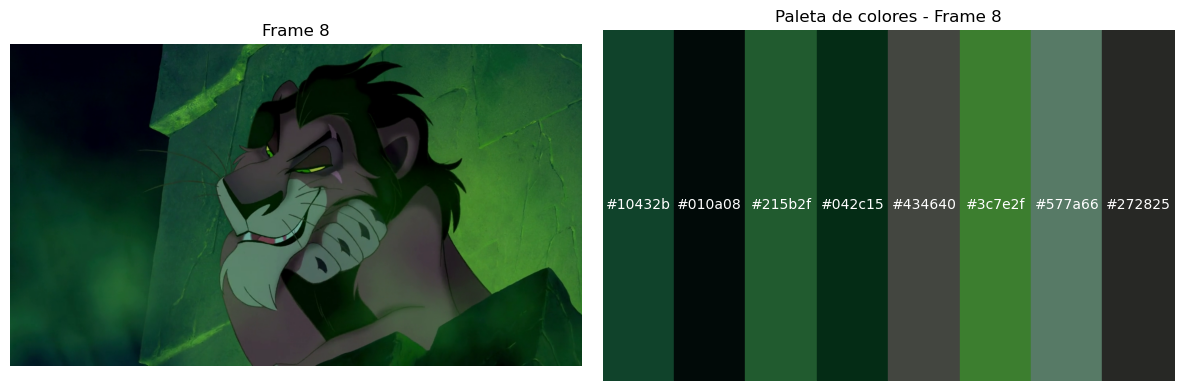

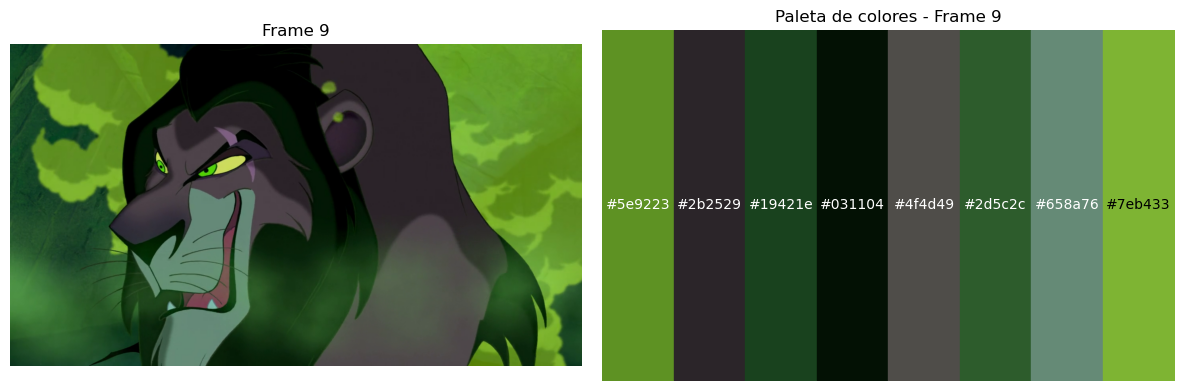

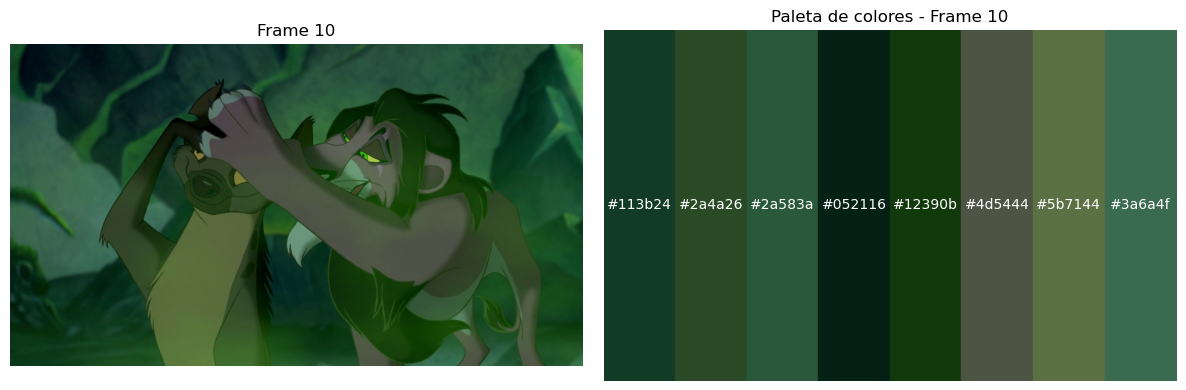

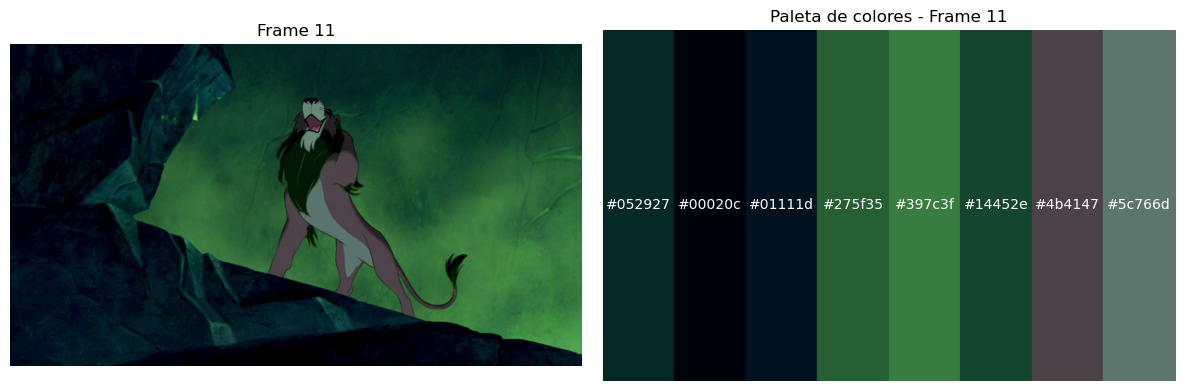

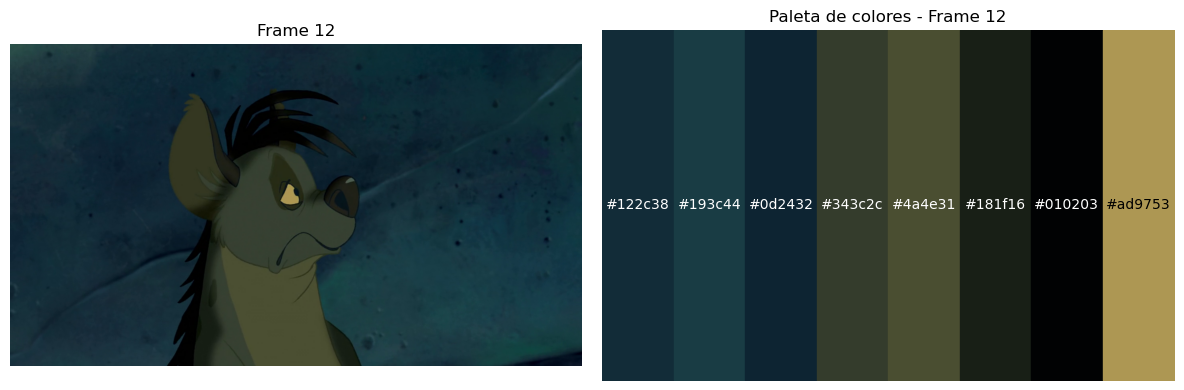

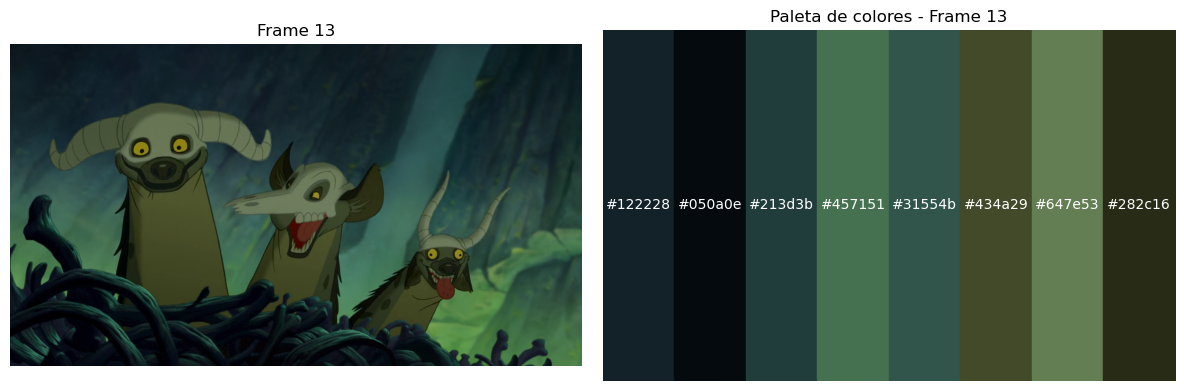

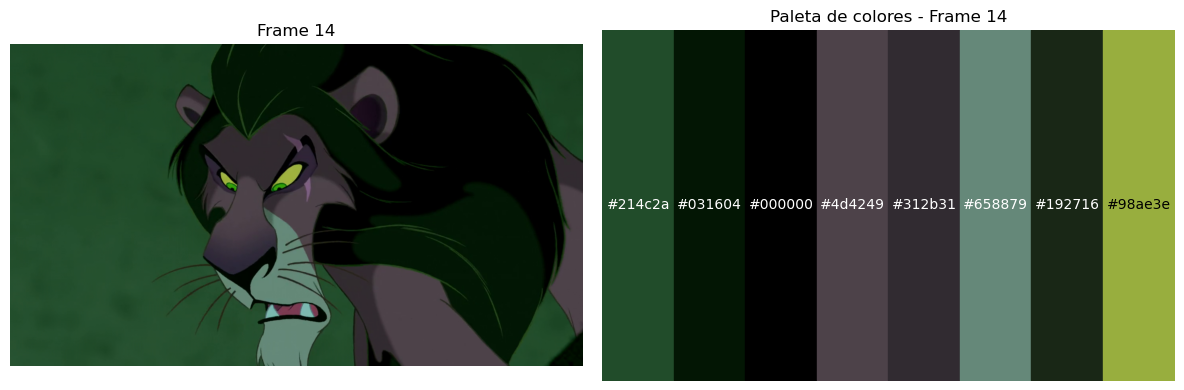

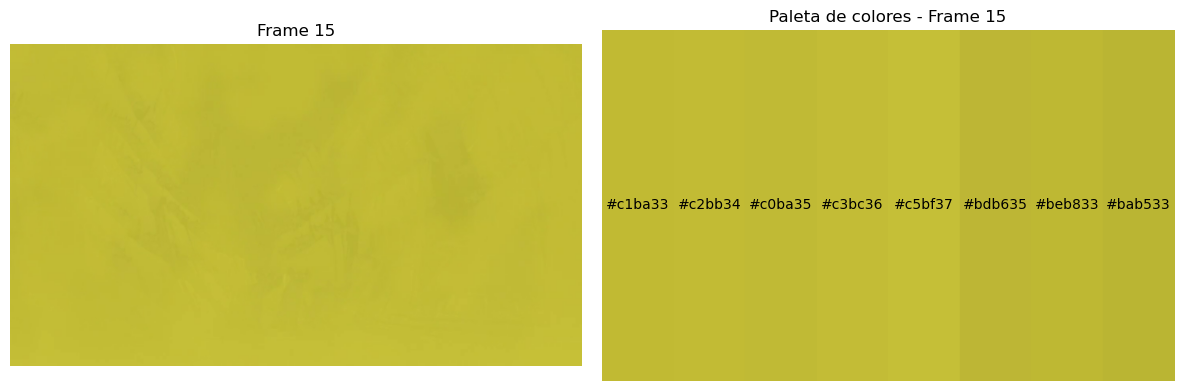

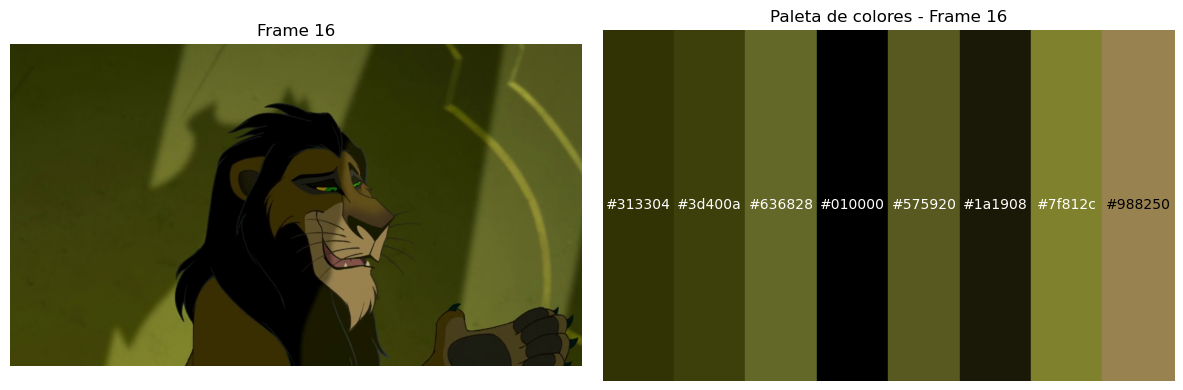

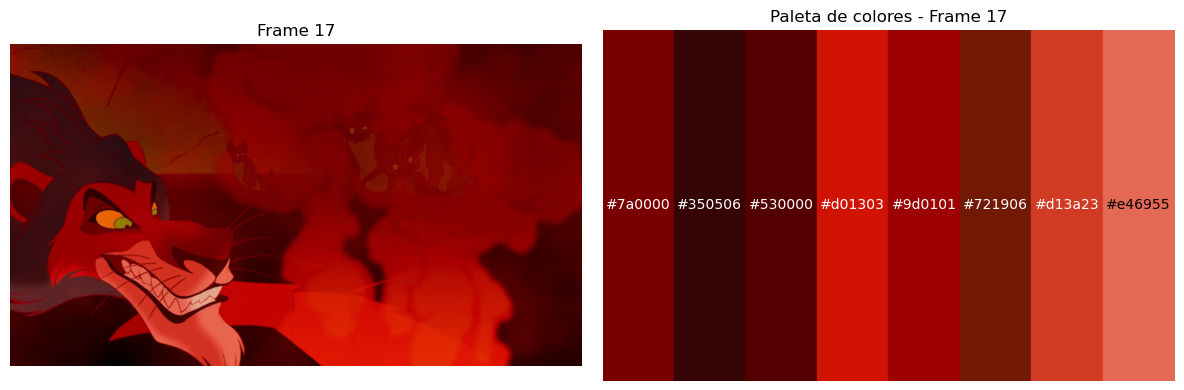

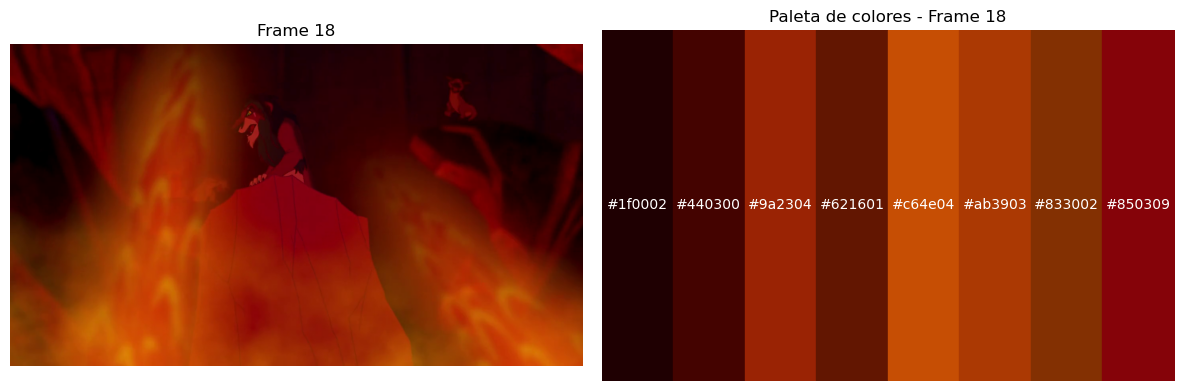

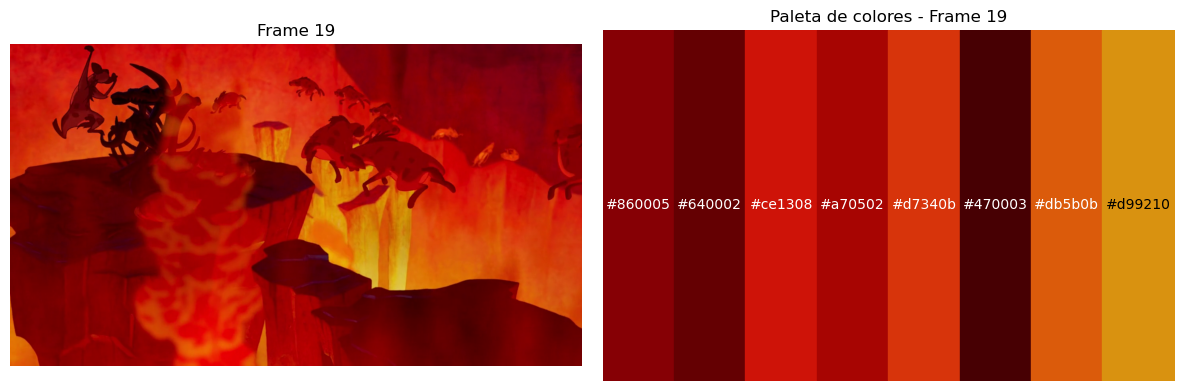

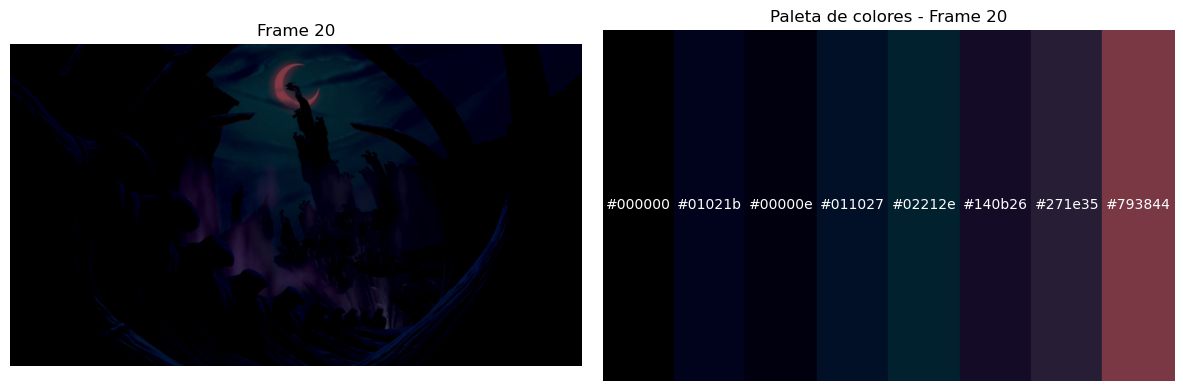


Generando paleta de color general del video:
Paleta de colores dominantes en todo el video:


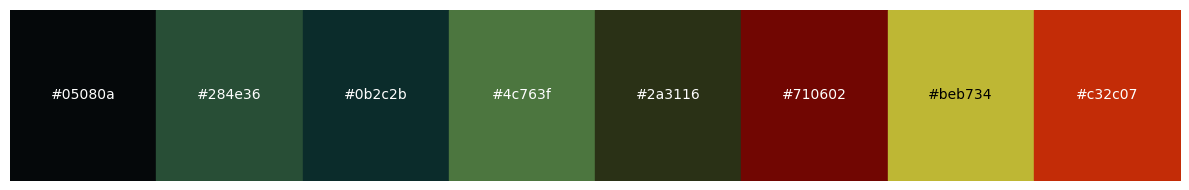


Código de barras cromático (progresión de colores):


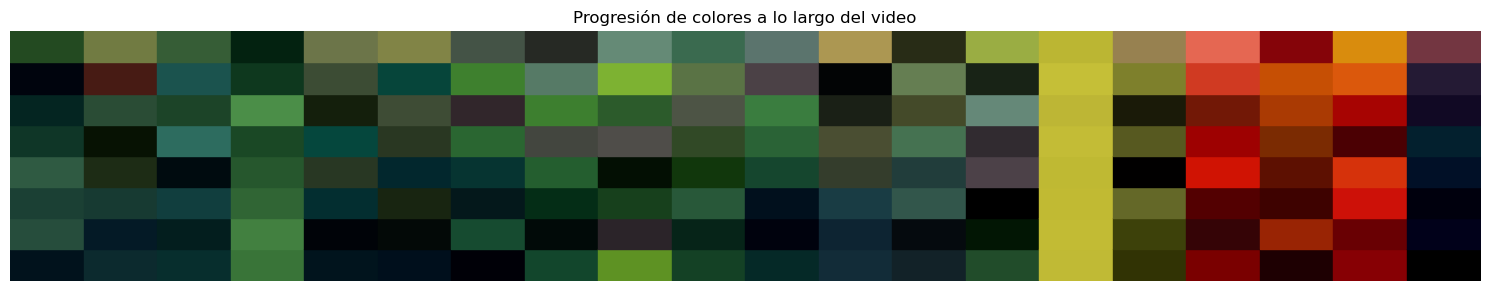


Análisis completado!


In [6]:
# Análisis de Paleta de Colores de Video
# Para ejecutar en Jupyter Notebook

# Instalación de dependencias (ejecutar esta celda si no tienes las bibliotecas)
# !pip install opencv-python numpy scikit-learn matplotlib

# Importar bibliotecas
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import os
from datetime import datetime
from IPython.display import display, Image

# Función para extraer frames de un video
def extract_frames(video_path, num_frames=10):
    """Extrae frames equidistantes de un video."""
    video = cv2.VideoCapture(video_path)
    if not video.isOpened():
        raise ValueError(f"No se pudo abrir el video: {video_path}")
    
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        video.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = video.read()
        if success:
            # Convertir de BGR a RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
    video.release()
    return frames

# Función para extraer colores dominantes
def get_dominant_colors(frame, n_colors=5):
    """Extrae los colores dominantes de un frame usando K-means."""
    # Redimensionar para acelerar el procesamiento
    pixels = frame.reshape(-1, 3)
    
    # Tomar una muestra aleatoria de píxeles para acelerar el procesamiento
    if len(pixels) > 10000:  # Limitar a 10,000 píxeles para acelerar
        pixels = pixels[np.random.choice(len(pixels), 10000, replace=False)]
    
    # Aplicar KMeans para encontrar los clusters de color
    kmeans = KMeans(n_clusters=n_colors, n_init=10)
    kmeans.fit(pixels)
    
    # Obtener los colores del centroide (colores dominantes)
    colors = kmeans.cluster_centers_.astype(int)
    
    # Ordenar por frecuencia (opcional)
    counts = np.bincount(kmeans.labels_)
    colors = colors[np.argsort(-counts)]
    
    return colors

# Función para visualizar paletas de colores
def plot_colors(colors, figsize=(12, 2)):
    """Dibuja los colores dominantes como una paleta."""
    plt.figure(figsize=figsize)
    
    # Crear una barra horizontal para cada color
    height = 1
    width = 1 / len(colors)
    
    for i, color in enumerate(colors):
        # Normalizar valores RGB a [0, 1]
        r, g, b = color / 255.0
        hex_color = to_hex([r, g, b])
        
        # Dibujar rectángulo coloreado
        plt.fill_between([i*width, (i+1)*width], 0, height, color=hex_color)
        
        # Mostrar el valor hex
        plt.text((i+0.5)*width, height/2, hex_color, 
                 ha='center', va='center', 
                 color='white' if (r*0.299 + g*0.587 + b*0.114) < 0.5 else 'black')
    
    plt.xlim(0, 1)
    plt.ylim(0, height)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Función para crear un "código de barras" de colores
def create_color_barcode(frames, n_colors_per_frame=5, figsize=(15, 3)):
    """Crea un 'código de barras' de colores representando la progresión del video."""
    all_colors = []
    
    for frame in frames:
        colors = get_dominant_colors(frame, n_colors_per_frame)
        all_colors.append(colors)
    
    # Crear la figura para el código de barras
    plt.figure(figsize=figsize)
    
    # Para cada frame y sus colores dominantes
    for i, frame_colors in enumerate(all_colors):
        frame_width = 1 / len(all_colors)
        color_height = 1 / len(frame_colors)
        
        # Para cada color en el frame
        for j, color in enumerate(frame_colors):
            r, g, b = color / 255.0
            x_start = i * frame_width
            x_end = (i + 1) * frame_width
            
            # Dibujar el rectángulo de color
            plt.fill_between([x_start, x_end], j * color_height, (j + 1) * color_height, 
                           color=[r, g, b])
    
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis('off')
    plt.title("Progresión de colores a lo largo del video")
    plt.tight_layout()
    plt.show()

# Función principal para analizar un video
def analyze_video_colors(video_path, num_frames=20, n_colors=8, display_frames=True):
    """Analiza los colores de un video y muestra visualizaciones en el notebook."""
    print(f"Analizando video: {video_path}")
    print(f"Extrayendo {num_frames} frames...")
    
    # Extraer frames
    frames = extract_frames(video_path, num_frames)
    print(f"Se extrajeron {len(frames)} frames.")
    
    # Mostrar los frames extraídos (opcional)
    if display_frames:
        plt.figure(figsize=(15, 8))
        for i, frame in enumerate(frames):
            if i < 6:  # Limitar a 6 frames para no sobrecargar el notebook
                plt.subplot(2, 3, i+1)
                plt.imshow(frame)
                plt.axis('off')
                plt.title(f"Frame {i+1}")
        plt.tight_layout()
        plt.show()
    
    # Analizar cada frame y mostrar sus paletas
    print("\nAnalizando paletas de color por frame:")
    for i, frame in enumerate(frames[:num_frames]):  # Mostrar los primeros 5 frames
        plt.figure(figsize=(12, 4))
        
        # Mostrar el frame
        plt.subplot(1, 2, 1)
        plt.imshow(frame)
        plt.axis('off')
        plt.title(f"Frame {i+1}")
        
        # Extraer y mostrar colores
        colors = get_dominant_colors(frame, n_colors)
        plt.subplot(1, 2, 2)
        height = 1
        width = 1 / len(colors)
        
        for j, color in enumerate(colors):
            r, g, b = color / 255.0
            hex_color = to_hex([r, g, b])
            plt.fill_between([j*width, (j+1)*width], 0, height, color=hex_color)
            plt.text((j+0.5)*width, height/2, hex_color, 
                    ha='center', va='center', 
                    color='white' if (r*0.299 + g*0.587 + b*0.114) < 0.5 else 'black')
        
        plt.xlim(0, 1)
        plt.ylim(0, height)
        plt.axis('off')
        plt.title(f"Paleta de colores - Frame {i+1}")
        
        plt.tight_layout()
        plt.show()
    
    # Crear paleta general del video
    print("\nGenerando paleta de color general del video:")
    all_frames = np.vstack([frame.reshape(-1, 3) for frame in frames])
    
    # Muestra aleatoria para acelerar
    if len(all_frames) > 50000:
        all_frames = all_frames[np.random.choice(len(all_frames), 50000, replace=False)]
    
    kmeans = KMeans(n_clusters=n_colors, n_init=10)
    kmeans.fit(all_frames)
    overall_colors = kmeans.cluster_centers_.astype(int)
    
    # Ordenar por frecuencia
    counts = np.bincount(kmeans.labels_, minlength=n_colors)
    overall_colors = overall_colors[np.argsort(-counts)]
    
    # Mostrar paleta general
    print("Paleta de colores dominantes en todo el video:")
    plot_colors(overall_colors)
    
    # Crear "barcode" de la película
    print("\nCódigo de barras cromático (progresión de colores):")
    create_color_barcode(frames, n_colors_per_frame=n_colors)
    
    print("\nAnálisis completado!")

# Ejemplo de uso (descomenta y modifica con tu ruta de video)
# video_path = "ruta/a/tu/video.mp4"  # Cambia esto a la ruta de tu video
# analyze_video_colors(video_path, num_frames=20, n_colors=8)

# Código adicional: Análisis comparativo entre escenas
def compare_scenes(video_path, scene_timestamps, n_colors=8):
    """
    Compara las paletas de color entre diferentes escenas de un video.
    
    Args:
        video_path: Ruta al archivo de video
        scene_timestamps: Lista de tuplas (inicio, fin) en segundos para cada escena
        n_colors: Número de colores a extraer por escena
    """
    video = cv2.VideoCapture(video_path)
    if not video.isOpened():
        raise ValueError(f"No se pudo abrir el video: {video_path}")
    
    fps = video.get(cv2.CAP_PROP_FPS)
    
    scene_frames = []
    scene_names = []
    
    for i, (start, end) in enumerate(scene_timestamps):
        # Convertir tiempos en segundos a números de frame
        start_frame = int(start * fps)
        end_frame = int(end * fps)
        
        # Número de frames a extraer de esta escena
        n_scene_frames = min(5, max(1, (end_frame - start_frame) // 20))
        
        frames_indices = np.linspace(start_frame, end_frame, n_scene_frames, dtype=int)
        scene_frames_list = []
        
        for idx in frames_indices:
            video.set(cv2.CAP_PROP_POS_FRAMES, idx)
            success, frame = video.read()
            if success:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                scene_frames_list.append(frame)
        
        if scene_frames_list:
            scene_frames.append(scene_frames_list)
            scene_names.append(f"Escena {i+1} ({start}s - {end}s)")
    
    video.release()
    
    # Analizar cada escena
    print(f"Comparando {len(scene_frames)} escenas...")
    
    plt.figure(figsize=(15, len(scene_frames) * 3))
    
    for i, (frames, name) in enumerate(zip(scene_frames, scene_names)):
        # Combinar todos los frames de la escena para análisis
        all_pixels = np.vstack([frame.reshape(-1, 3) for frame in frames])
        
        # Muestra para acelerar
        if len(all_pixels) > 20000:
            all_pixels = all_pixels[np.random.choice(len(all_pixels), 20000, replace=False)]
        
        # Extraer colores dominantes
        kmeans = KMeans(n_clusters=n_colors, n_init=10)
        kmeans.fit(all_pixels)
        colors = kmeans.cluster_centers_.astype(int)
        
        # Mostrar un frame representativo
        plt.subplot(len(scene_frames), 2, i*2 + 1)
        plt.imshow(frames[len(frames)//2])  # Frame del medio
        plt.title(name)
        plt.axis('off')
        
        # Mostrar paleta
        plt.subplot(len(scene_frames), 2, i*2 + 2)
        height = 1
        width = 1 / len(colors)
        
        for j, color in enumerate(colors):
            r, g, b = color / 255.0
            hex_color = to_hex([r, g, b])
            plt.fill_between([j*width, (j+1)*width], 0, height, color=hex_color)
            plt.text((j+0.5)*width, height/2, hex_color, 
                    ha='center', va='center', 
                    color='white' if (r*0.299 + g*0.587 + b*0.114) < 0.5 else 'black',
                    fontsize=8)
        
        plt.xlim(0, 1)
        plt.ylim(0, height)
        plt.axis('off')
        plt.title(f"Paleta de colores - {name}")
    
    plt.tight_layout()
    plt.show()

# Ejemplo de uso de comparación de escenas (descomenta y ajusta)
# Definir escenas por tiempo (inicio, fin) en segundos
# scenes = [
#     (0, 30),     # Escena 1: 0s - 30s
#     (45, 60),    # Escena 2: 45s - 60s
#     (120, 150)   # Escena 3: 2min - 2min30s
# ]
# compare_scenes("ruta/a/tu/video.mp4", scenes, n_colors=6)

# compare_scenes("ruta/a/tu/video.mp4", scenes, n_colors=6)


video_path = "escena.mp4"  # Cambia esto a la ruta de tu video
analyze_video_colors(video_path, num_frames=20, n_colors=8)